# Project: BBLF AI Selector v2 
# Section: Model Pipeline - All Expected Points Model
## Sub Section: During Tourny (Post Game 5)

Goal: Develop the most robust and predictive model to forecast the players' expected fantasy points for BBL15

Things to add:
2. CatBoost Model Pipeline

In [55]:
# pip install --upgrade scikit-learn xgboost interpret

# Prerequistes

In [56]:
# 0. Prerequistes

import pandas as pd
import numpy as np
import math
import os
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import (DecisionTreeRegressor, plot_tree, export_text)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor  
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error,root_mean_squared_error, mean_absolute_percentage_error, r2_score
import statsmodels.api as sm
from statsmodels.api import OLS
import sklearn.model_selection as skm
from sklearn.model_selection import GridSearchCV 
import xgboost as xgb
from xgboost import XGBRegressor
import joblib

import warnings
warnings.filterwarnings("ignore")

  # Interpret
import interpret
from interpret import show
from interpret.data import Marginal
from interpret.glassbox import ExplainableBoostingRegressor

os.getcwd()
py_data_directory = 'C:/Users/dilan/OneDrive/Documents/Data Science Projects/Repos/Big-Bash-Fantasy-AI-v2/data/python_data/model/post-game-5/'
py_model_directory = 'C:/Users/dilan/OneDrive/Documents/Data Science Projects/Repos/Big-Bash-Fantasy-AI-v2/python_script/model/build/models/'

# Data Extraction

In [57]:
# 1. Data Extraction 
# Pull in model_data csv file 

model_df = pd.read_csv(os.path.join(py_data_directory,'bblf_v2_model_data_pg5.csv'), low_memory=False)

# Rename response variable for easy reference
if 'resp_var_bowl' in model_df.columns:    
    model_df = model_df.rename(columns={"resp_var_bowl":"resp_var"})
    print("Response variable changed to correct format")
elif 'resp_var_bat' in model_df.columns:
    model_df = model_df.rename(columns={"resp_var_bat":"resp_var"})
    print("Response variable changed to correct format")
elif 'resp_var_sd' in model_df.columns:
    model_df = model_df.rename(columns={"resp_var_sd":"resp_var"})
    print("Response variable changed to correct format")
else:
    print("Response variable already correct format")

# Create dataframe with NA values removed
model_df_NA_rm = model_df.dropna()
len(model_df_NA_rm)

Response variable already correct format


86

# Pipeline Parameters

In [58]:
save_mdl = True  # Set to True to save model object
model_name = "ps_all_mdl_pg5_3"  # Pipeline model name (Set to the next iteration to not overwrite previous models)

# Feature Selection

In [59]:
# 2. Feature Selection
    # Dropping Columns & Create Split Data prior to modelling
col_names = model_df.columns
print (col_names)

# other_var_drop = ["resp_var", "Unnamed: 0","season", "player", "team", "match_id"]
other_var_drop = ["resp_var", "season", "player"]


# total point feat_drop
feat_drop = [
            # "avg_over_3_f_lag2",
            # "bat_pos_4_lag3",
            # "bat_pos_10_lag1",
            # "avg_bat_cat_Tail_lag2",
            # "max_season_fp_srg_lag1",
            # "min_season_fp_ebg_lag3",
            # "max_bat_cat_LM_lag3",
            # "avg_season_fp_wbg_lag1",
            # "bat_pos_4_lag1",
            # "min_over_cat_Death_lag2",
            # "max_bat_cat_Tail_lag2",
            # "min_bat_cat_Tail_lag3",
            # "over_19_f_lag3",
            # "min_season_econ_lag1",
            # "bat_pos_4_lag2",
            # "avg_over_1_f_lag3",
            # "bat_pos_9_lag2",
            # "over_15_f_lag3",
            # "bat_pos_9_lag1",
            # "min_bat_cat_Open_lag3",
            # "over_12_f_lag2",
            # "over_11_f_lag1",
            # "over_1_f_lag1",
            # "over_18_f_lag3",
            # "over_2_f_lag2",
            # "over_20_f_lag1",
            # "min_over_cat_PP_lag3",
            # "over_3_f_lag2",
            # "over_6_f_lag3",
            # "over_18_f_lag1",
            # "over_13_f_lag2",
            # "over_20_f_lag3",
            # "bat_pos_10_lag3",
            # "max_bat_cat_LM_lag3",
            # "min_over_cat_EM_lag1",
            # "min_season_wick_lag1",
            # "min_bat_cat_Tail_lag1",
            # "min_season_fp_ebg_lag1",
            # "min_over_cat_Death_lag3",
            # "min_season_fp_srg_lag3",
            # "min_season_extras_lag3",
            # "min_season_fp_srg_lag2",
            # "over_4_f_lag1",
            # "min_season_econ_lag2",
            # "min_season_extras_lag1",
            # "max_bat_cat_LM_lag2",
            # "bat_pos_11_lag2",
            # "max_bat_cat_Tail_lag3",
            # "bat_pos_11_lag3",
            # "min_bat_cat_Tail_lag2",
            # "min_season_extras_lag3",
            # "min_season_fp_srg_lag1",
            # "avg_season_fp_wbg_lag2",
            # "avg_over_20_f_lag1",
            # "avg_bat_pos_10_lag3",
            # "avg_over_4_f_lag2",
            # "max_bat_cat_Tail_lag1",
            # "bat_pos_3_lag2",
            # "bat_pos_7_lag2",
            # "avg_over_11_f_lag1",
            # "bat_pos_5_lag2",
            # "bat_pos_1_lag2",
            # "avg_bat_pos_4_lag1",
            # "avg_bat_pos_9_lag1",
            # "avg_over_19_f_lag2",
            # "min_over_cat_LM_lag3",
            # "avg_over_13_f_lag2",
            # "avg_over_14_f_lag1",
            # "max_bat_cat_TM_lag3",
            # "bat_pos_1_lag1",
            # "bat_pos_5_lag1",
            # "over_2_f_lag1",
            # "over_9_f_lag3",
            # "avg_over_20_f_lag3",
            # "over_10_f_lag1",
            # "bat_pos_1_lag3",
            # "max_bat_cat_TM_lag1",
            # "avg_bat_pos_8_lag2",
            # "avg_bat_pos_11_lag3",
            # "over_12_f_lag1",
            # "over_5_f_lag2",
            # "bat_pos_6_lag3",
            # "over_14_f_lag2",
            # "max_season_fp_ebg_lag3",
            # "bat_pos_3_lag1",
            # "over_4_f_lag3",
            # "bat_pos_8_lag2",
            # "over_9_f_lag2",
            # "bat_pos_2_lag2",
            # "avg_bat_cat_Tail_lag3",
            # "max_season_econ_lag1",
            # "bat_pos_11_lag1",
            # "max_over_cat_EM_lag1",
            # "over_2_f_lag3",
            # "bat_pos_2_lag3",
            # "over_8_f_lag3",
            # "over_4_f_lag2",
            # "bat_pos_9_lag3",
            # "bat_pos_11_lag1",
            # "max_bat_cat_Open_lag2",
            # "min_season_extras_lag2",
            # "min_bat_cat_Open_lag1",
            # "min_bat_cat_LM_lag1",
            # "over_3_f_lag3",
            # "sd_over_cat_EM_lag2",
            # "avg_bat_cat_TM_lag2",
            # "avg_bat_pos_4_lag3",
            # "min_season_strike_lag3",
            # "max_season_fp_srg_lag3",
            # "min_season_fp_bowl_lag2",
            # "sd_bat_cat_LM_lag2",
            # "bowl_cnt_lag1",
            # "avg_season_econ_lag2",
            # "sd_season_bat_pos_lag3",
            # "min_over_cat_Death_lag1",
            # "max_over_cat_PP_lag1",
            # "sd_bat_cat_Open_lag2",
            # "avg_season_wick_lag2",
            # "avg_over_10_f_lag1",
            # "max_over_cat_Death_lag3",
            # "max_over_cat_LM_lag1",
            # "bat_pos_8_lag3",
            # "max_season_dots_lag3",
            # "bat_cnt_lag1",
            # "avg_bat_pos_2_lag2",
            # "avg_bat_pos_1_lag3",
            # "bat_cnt_lag3",
            # "over_10_f_lag3",
            # "avg_bat_pos_3_lag2",
            # "avg_over_6_f_lag3",
            # "sd_over_cat_Death_lag2",
            # "avg_bat_pos_5_lag2",
            # "avg_over_4_f_lag1",
            # "avg_season_wick_lag3",
            # "avg_over_6_f_lag2",
            # "avg_over_8_f_lag3",
            # "max_bat_cat_TM_lag2",
            # "avg_over_18_f_lag1",
            # "avg_bat_pos_2_lag3",
            # "max_season_wick_lag2",
            # "avg_over_1_f_lag2",
            # "max_season_strike_lag2",
            # "avg_over_9_f_lag2",
            # "sd_bat_cat_Open_lag3",
            # "over_14_f_lag1",
            # "avg_over_2_f_lag3",
            # "min_season_runs_lag1",
            # "sd_bat_cat_Tail_lag2",
            # "avg_over_17_f_lag2",
            # "sd_season_strike_lag1",
            # "max_season_extras_lag1",
            # "min_season_overs_lag1",
            # "avg_over_18_f_lag3",
            # "min_bat_cat_TM_lag3",
            # "min_season_overs_lag2",
            # "avg_over_4_f_lag3",
            # "min_season_strike_lag1",
            # "min_season_strike_lag2",
            # "sd_bat_cat_Tail_lag3",
            # "sd_over_cat_PP_lag3",
            # "over_8_f_lag2",
            # "avg_bat_pos_7_lag3",
            # "avg_season_extras_lag2",
            # "avg_over_cat_Death_lag3",
            # "avg_over_5_f_lag3",
            # "bat_pos_2_lag1",
            # "avg_over_2_f_lag1",
            # "over_16_f_lag1",
            # "min_season_dots_lag2",
            # "min_over_cat_EM_lag3",
            # "avg_bat_cat_Open_lag3",
            # "over_10_f_lag2",
            # "avg_over_16_f_lag1",
            # "avg_over_5_f_lag2",
            # "avg_season_strike_lag2",
            # "avg_bat_cat_TM_lag3",
            # "sd_bat_cat_LM_lag3",
            # "min_bat_cat_TM_lag2",
            # "sd_bat_cat_TM_lag2",
            # "avg_over_18_f_lag2",
            # "over_17_f_lag3",
            # "sd_over_cat_PP_lag1",
            # "sd_bat_cat_Tail_lag1",
            # "max_season_fp_ebg_lag1",
            # "min_season_fp_bowl_lag3",
            # "avg_bat_pos_8_lag3",
            # "min_season_dots_lag3",
            # "max_over_cat_PP_lag3",
            # "sd_season_fp_srg_lag2",
            # "over_19_f_lag2",
            # "avg_bat_cat_TM_lag2",
            # "sd_season_bat_pos_lag2",
            # "bat_pos_6_lag2",
            # "bat_pos_6_lag2",
            # "avg_bat_pos_6_lag2",
            # "min_season_fp_ebg_lag2",
            # "over_1_f_lag2",
            # "avg_bat_cat_LM_lag2",
            # "avg_bat_pos_9_lag2",
            # "bat_pos_9_lag2",
            # "over_19_f_lag1",
            # "min_over_cat_PP_lag1",
            # "over_8_f_lag1",
            # "over_6_f_lag1",
            # "min_season_econ_lag3",
            # "avg_over_19_f_lag3",
            # "min_season_wick_lag2",
            # "bat_pos_3_lag3",
            # "over_9_f_lag2",
            # "min_over_cat_LM_lag1",
            # "sd_season_dots_lag3",
            # "bat_pos_8_lag1",
            # "avg_season_overs_lag3",
            # "sd_season_extras_lag3",
            # "sd_season_fp_srg_lag3",
            # "avg_season_bat_pos_lag3",
            # "avg_season_fp_bowl_lag2",
            # "min_bat_cat_LM_lag3",
            # "avg_season_extras_lag1",
            # "avg_season_fp_ere_lag2",
            # "sd_season_strike_lag2",
            # "avg_over_11_f_lag3",
            # "avg_bat_pos_11_lag2",
            # "avg_over_8_f_lag2",
            # "over_18_f_lag2",
            # "avg_over_cat_PP_lag3",
            # "avg_bat_pos_9_lag3",
            # "over_6_f_lag2",
            # "sd_season_overs_lag2",
            # "avg_over_cat_EM_lag3",
            # "sd_bat_cat_LM_lag1",
            # "avg_over_16_f_lag2",
            # "bat_cnt_lag2",
            # "bowl_cnt_lag3",
            # "sd_over_cat_Death_lag3",
            # "sd_season_fp_ebg_lag1",
            # "avg_over_6_f_lag1",
            # "avg_bat_pos_5_lag1",
            # "min_over_cat_LM_lag2",
            # "min_season_fp_bowl_lag1",
            # "avg_season_dots_lag3",
            # "min_season_overs_lag3",
            # "over_5_f_lag1",
            # "avg_over_12_f_lag2",
            # "sd_over_cat_EM_lag1",
            # "bat_pos_7_lag1",
            # "bowl_cnt_lag2",
            # "avg_season_fp_ere_lag3",
            # "avg_bat_cat_TM_lag1",
            # "avg_over_13_f_lag3",
            # "avg_over_10_f_lag2",
            # "min_over_cat_PP_lag2",
            # "avg_bat_pos_7_lag2",
            # "avg_over_15_f_lag3",
            # "avg_season_econ_lag1",
            # "min_season_wick_lag3",
            # "over_7_f_lag2",
            # "over_1_f_lag3",
            # "over_5_f_lag3",
            # "bat_pos_7_lag3",
            # "bat_pos_5_lag3",
            # "over_17_f_lag1",
            # "avg_over_3_f_lag1",
            # "min_season_fp_lag3",
            # "avg_over_2_f_lag2",
            # "sd_over_cat_PP_lag2",
            # "sd_bat_cat_TM_lag1",
            # "avg_season_econ_lag3",
            # "avg_over_cat_EM_lag1",
            # "avg_bat_pos_11_lag1",
            # "min_season_runs_lag3",
            # "sd_over_cat_EM_lag1",
            # "avg_over_1_f_lag1",
            # "avg_bat_pos_4_lag2",
            # "avg_over_9_f_lag3",
            # "max_season_wick_lag3",
            # "avg_over_17_f_lag3",
            # "sd_season_fp_srg_lag1",
            # "sd_season_wick_lag3",
            # "sd_season_bat_pos_lag1",
            # "min_season_fp_lag2",
            # "min_season_fp_bat_lag1",
            # "max_season_strike_lag1",
            # "max_season_fp_srg_lag2",
            # "max_season_extras_lag2",
            # "max_season_strike_lag3",
            # "max_bat_cat_Open_lag1",
            # "avg_over_12_f_lag1",
            # "avg_over_16_f_lag3",
            # "max_season_econ_lag3",
            # "sd_season_overs_lag3",
            # "avg_over_7_f_lag1",
            # "avg_season_fp_wbg_lag3",
            # "avg_bat_pos_3_lag3",
            # "over_3_f_lag1",
            # "avg_bat_pos_1_lag1",
            # "avg_over_7_f_lag2",
            # "avg_bat_cat_LM_lag3",
            # "avg_season_fp_srg_lag2",
            # "sd_season_fp_ebg_lag2",
            # "avg_season_fp_ebg_lag3",
            # "avg_over_13_f_lag1",
            # "max_season_econ_lag2",
            # "avg_over_8_f_lag1",
            # "avg_over_3_f_lag3",
            # "sd_season_fp_ebg_lag3",
            # "max_over_cat_Death_lag2",
            # "over_7_f_lag3",
            # "over_17_f_lag1",
            # "avg_over_17_f_lag2",
            # "max_bat_cat_Open_lag3",
            # "over_9_f_lag1",
            # "max_bat_cat_LM_lag1",
            # "sd_season_runs_lag2",
            # "min_season_runs_lag2",
            # "avg_bat_pos_8_lag1",
            # "max_over_cat_EM_lag3",
            # "sd_over_cat_EM_lag3",
            # "sd_season_runs_lag3",
            # "sd_season_fp_bowl_lag3",
            # "avg_over_14_f_lag3",
            # "sd_season_fp_bat_lag3",
            # "sd_season_econ_lag1",
            # "sd_season_fp_bat_lag3",
            # "max_season_runs_lag2",
            # "sd_bat_cat_Open_lag1",
            # "season_fp_lag3",
            # "avg_over_9_f_lag1",
            # "sd_season_fp_lag3",
            # "sd_season_overs_lag3",
            # "max_season_fp_ebg_lag2",
            # "over_16_f_lag2",
            # "avg_bat_pos_6_lag3",
            # "avg_season_fp_ebg_lag2",
            # "avg_over_14_f_lag2",
            # "min_season_bat_pos_lag2",
            # "sd_season_strike_lag3",
            # "avg_over_10_f_lag3",
            # "avg_over_cat_EM_lag2",
            # "max_over_cat_EM_lag2",
            # "avg_season_extras_lag3",
            # "min_bat_cat_TM_lag1",
            # "min_season_bat_pos_lag3",
            # "avg_season_fp_bowl_lag3",
            # "over_13_f_lag3",
            # "max_season_wick_lag1",
            # "over_17_f_lag2",
            # "over_7_f_lag1",
            # "over_13_f_lag1",
            # "avg_over_15_f_lag1",
            # "avg_over_cat_PP_lag2",
            # "avg_bat_pos_1_lag2",
            # "sd_season_fp_lag1",
            # "sd_over_cat_LM_lag1",
            # "min_season_dots_lag1",
            # "sd_season_fp_bat_lag2",
            # "max_season_dots_lag2",
            # "avg_season_runs_lag3",
            # "avg_over_12_f_lag3",
            # "sd_season_dots_lag2",
            # "avg_bat_pos_2_lag1",
            # "min_season_fp_bat_lag3",
            # "avg_season_strike_lag2",
            # "max_over_cat_PP_lag2",
            # "bat_pos_6_lag1",
            # "avg_season_bat_pos_lag2",
            # "max_season_fp_lag3",
            # "max_season_fp_bowl_lag3",
            # "avg_over_5_f_lag1",
            # "max_season_bat_pos_lag1",
            # "avg_over_11_f_lag2",
            # "avg_season_strike_lag1",
            # "over_14_f_lag3",
            # "avg_season_fp_srg_lag3",
            # "max_season_runs_lag3",
            # "max_season_fp_bat_lag3",
            # "sd_bat_cat_TM_lag3",
            # "avg_bat_pos_10_lag1",
            # "avg_season_wick_lag2",
            # "avg_season_dots_lag2",
            # "max_season_extras_lag3",
            # "max_season_bat_pos_lag3",
            # "max_season_fp_bowl_lag2",
            # "avg_bat_pos_10_lag2",
            # "over_11_f_lag3",
            # "avg_bat_pos_5_lag3",
            # "sd_season_overs_lag1",
            # "max_season_overs_lag3",
            # "over_16_f_lag3",
            # "sd_season_econ_lag2",
            # "min_over_cat_EM_lag2",
            # "avg_over_7_f_lag3",
            # "min_bat_cat_LM_lag2",
            # "avg_season_runs_lag2",
            # "max_season_bat_pos_lag2",
            # "sd_season_wick_lag2",
            # "over_11_f_lag2",
            # "avg_season_fp_sre_lag2",
            # "sd_season_fp_lag2",
            # "avg_season_fp_rbg_lag3",
            # "avg_over_15_f_lag2",
            # "sd_season_extras_lag2",
            # "sd_season_runs_lag1",
            # "season_fp_lag2",
            # "min_season_fp_bat_lag2",
            # "avg_season_fp_bat_lag3",
            # "min_season_fp_lag1",
            # "min_season_bat_pos_lag1",
            # "avg_over_cat_Death_lag2",
            # "sd_over_cat_LM_lag3",
            # "avg_bat_pos_7_lag1",
            # "over_15_f_lag2",
            # "over_12_f_lag3",
            # "avg_season_fp_sre_lag1",
            # "avg_season_strike_lag3",
            # "avg_bat_pos_3_lag1",
            # "sd_season_fp_bowl_lag2",
            # "over_15_f_lag1",
            # "avg_bat_cat_Tail_lag1",
            # "avg_over_cat_LM_lag3",
            # "avg_over_17_f_lag1",
            # "max_over_cat_LM_lag3",
            # "sd_season_econ_lag3"          

            # New drops
            "over_16_f_lag1",
    "min_season_econ_lag2",
    "min_season_fp_ebg_lag2",
    "max_bat_cat_Tail_lag2",
    "over_2_f_lag2",
    "min_over_cat_Death_lag1",
    "min_season_econ_lag1",
    "min_season_fp_ebg_lag3",
    "min_season_fp_srg_lag2",
    "min_over_cat_PP_lag2",
    "min_season_fp_srg_lag3",
    "min_season_extras_lag1",
    "min_season_extras_lag2",
    "min_season_wick_lag2",
    "avg_bat_pos_11_lag1",
    "bat_pos_11_lag3",
    "avg_bat_pos_10_lag3",
    "min_bat_cat_Tail_lag3",
    "min_over_cat_EM_lag1",
    "over_14_f_lag1",
    "over_1_f_lag1",
    "over_20_f_lag2",
    "max_bat_cat_Open_lag2",
    "over_8_f_lag1",
    "over_12_f_lag1",
    "over_10_f_lag1",
    "over_16_f_lag2",
    "bat_pos_7_lag3",
    "bat_pos_8_lag3",
    "min_bat_cat_TM_lag3",
    "max_bat_cat_Tail_lag3",
    "max_bat_cat_Open_lag3",
    "min_bat_cat_LM_lag3",
    "over_20_f_lag3",
    "over_18_f_lag3",
    "min_over_cat_EM_lag3",
    "min_over_cat_Death_lag3",
    "min_bat_cat_Open_lag2",
    "min_season_wick_lag3",
    "min_bat_cat_Tail_lag2",
    "min_bat_cat_LM_lag2",
    "min_bat_cat_TM_lag1",
    "max_bat_cat_TM_lag1",
    "max_bat_cat_Tail_lag1",
    "min_bat_cat_LM_lag2",
    "bat_pos_1_lag1",
    "min_season_extras_lag3",
    "min_bat_cat_TM_lag2",
    "over_14_f_lag2",
    "min_season_econ_lag3",
    "bat_pos_11_lag1",
    "min_season_fp_ebg_lag1",
    "min_season_fp_srg_lag1",

    "bat_pos_8_lag2",
    "avg_over_10_f_curr",
    "over_9_f_lag3",
    "sd_over_cat_PP_lag3",
    "sd_bat_cat_LM_lag1",
    "over_6_f_lag1",
    "avg_bat_cat_Tail_lag3",
    "avg_over_12_f_lag1",
    "avg_over_8_f_lag3",
    "avg_over_9_f_curr",
    "avg_over_3_f_lag1",
    "over_10_f_lag3",
    "bat_pos_4_lag1",
    "avg_bat_pos_5_curr",
    "avg_over_4_f_lag2",
    "over_5_f_lag3",
    "avg_over_16_f_lag3",
    "max_season_fp_srg_lag3",
    "min_season_runs_lag3",
    "min_season_overs_lag3",
    "avg_over_3_f_lag2",
    "sd_season_econ_lag3",
    "avg_over_19_f_lag3",
    "avg_over_10_f_lag1",
    "avg_over_12_f_curr",
    "bat_pos_5_lag1",
    "over_13_f_lag2",
    "over_19_f_lag2",
    "sd_bat_cat_LM_lag3",
    "avg_over_11_f_lag1",
    "avg_over_1_f_lag1",
    "avg_bat_cat_Tail_curr",
    "over_2_f_lag1",
    "bat_pos_7_lag1",
    "over_15_f_lag2",
    "bat_pos_5_lag2",
    "max_bat_cat_LM_lag1",
    "avg_bat_pos_11_curr",
    "over_17_f_lag2",
    "max_bat_cat_LM_lag3",
    "bat_pos_10_lag3",
    "over_18_f_lag1",
    "over_2_f_lag3",
    "bat_pos_2_lag1",
    "avg_bat_pos_11_lag2",
    "bat_pos_9_lag1",
    "bat_pos_4_lag3",
    "avg_bat_pos_8_lag3",
    "avg_over_3_f_lag1",
    "over_1_f_lag2",
    "over_9_f_lag2",
    "bat_pos_10_lag2",

        "max_over_cat_Death_lag3",
    "avg_over_16_f_curr",
    "avg_over_18_f_lag3",
    "sd_over_cat_PP_lag1",
    "avg_over_13_f_lag1",
    "avg_bat_pos_6_lag3",
    "avg_bat_cat_TM_lag1",
    "avg_bat_pos_10_lag1",
    "bat_pos_3_lag1",
    "sd_season_extras_lag3",
    "avg_season_fp_wbg_lag2",
    "min_over_cat_PP_lag3",
    "max_season_fp_srg_lag2",
    "avg_over_8_f_lag1",
    "avg_over_19_f_curr",
    "min_season_strike_lag3",
    "avg_bat_cat_TM_lag3",
    "bowl_cnt_lag3",
    "sd_season_strike_lag3",
    "bat_cnt_lag3",
    "avg_over_15_f_lag1",
    "avg_bat_pos_4_lag1",
    "avg_season_econ_lag1",
    "avg_over_8_f_lag2",
    "max_over_cat_EM_lag3",
    "avg_over_18_f_lag1",
    "avg_bat_pos_4_curr",
    "sd_over_cat_LM_lag1",
    "sd_bat_cat_Tail_lag3",
    "avg_over_19_f_curr",
    "avg_over_14_f_lag3",
    "avg_over_14_f_curr",
    "avg_over_20_f_lag1",
    "avg_bat_pos_8_lag1",
    "avg_season_fp_wbg_lag3",
    "avg_over_6_f_lag1",
    "min_over_cat_LM_lag2",
    "avg_over_3_f_curr",
    "min_season_fp_bowl_lag3",
    "over_18_f_lag2",
    "bat_cnt_lag2",
    "min_season_fp_lag2",
    "max_bat_cat_TM_lag2",
    "min_season_runs_lag2",
    "bat_pos_9_lag3",
    "over_1_f_lag3",
    "over_9_f_lag1",
    "bat_pos_6_lag1",
    "avg_bat_pos_5_lag3",
    "avg_bat_pos_10_curr",
    "avg_bat_pos_4_lag3",

    "avg_bat_pos_6_curr",
    "sd_season_econ_lag1",
    "min_season_overs_lag2",
    "max_season_wick_lag3",
    "avg_bat_pos_8_curr",
    "max_games_team_lag3",
    "sd_season_bat_pos_lag3",
    "seas_match_prop_lag3",
    "sd_season_runs_lag3",
    "avg_bat_cat_TM_curr",
    "over_11_f_lag1",
    "avg_bat_pos_3_curr",
    "avg_over_2_f_lag2",
    "avg_over_17_f_lag2",
    "sd_season_fp_srg_lag2",
    "bowl_cnt_lag2",
    "avg_over_5_f_lag2",
    "avg_over_cat_Death_lag3",
    "avg_over_cat_PP_lag1",
    "max_season_dots_lag1",
    "min_season_fp_lag3",
    "min_season_runs_lag1",
    "max_season_fp_bat_lag1",
    "sd_season_bat_pos_lag1",
    "sd_season_wick_lag3",
    "over_20_f_lag1",
    "max_season_strike_lag2",
    "bat_pos_2_lag2",
    "max_games_team_lag1",
    "avg_over_16_f_lag2",
    "avg_over_13_f_lag3",
    "avg_over_5_f_lag3",
    "avg_over_2_f_curr",
    "avg_over_10_f_lag2",
    "max_over_cat_Death_lag2",
    "avg_season_dots_lag2",
    "bat_pos_4_lag2",
    "avg_season_fp_srg_lag3",
    "avg_bat_pos_11_lag1",
    "max_season_extras_lag2",
    "avg_bat_pos_7_lag3",
    "bat_pos_3_lag2",
    "avg_over_7_f_lag1",
    "avg_bat_pos_5_lag1",
    "avg_season_wick_lag2",
    "sd_season_fp_srg_lag3",
    "bat_pos_11_lag2",
    "sd_season_strike_lag2",
    "avg_bat_pos_4_lag2",
    "max_over_cat_LM_lag3",
    "avg_bat_pos_10_lag2",
    "avg_season_fp_sre_lag2",
    "avg_over_5_f_lag1",
    "max_over_cat_Death_lag3",

    "max_season_econ_lag3",
    "avg_bat_pos_3_lag1",
    "min_season_dots_lag3",
    "avg_bat_pos_6_lag2",
    "avg_over_7_f_lag3",
    "avg_season_fp_ere_lag3",
    "seas_match_prop_lag2",
    "over_3_f_lag1",
    "avg_season_extras_lag1",
    "over_3_f_lag2",
    "avg_over_20_f_lag3",
    "max_season_overs_lag3",
    "min_season_wick_lag1",
    "max_games_team_lag2",
    "avg_over_11_f_lag3",
    "avg_over_12_f_lag2",
    "over_4_f_lag2",
    "avg_bat_pos_9_lag1",
    "max_over_cat_EM_lag2",
    "max_season_econ_lag1",
    "avg_over_19_f_lag2",
    "avg_season_fp_ere_lag2",
    "over_13_f_lag3",
    "max_season_extras_lag1",
    "max_season_extras_lag3",
    "max_season_econ_lag2",
    "bat_pos_1_lag2",
    "bat_pos_8_lag1",
    "over_12_f_lag2",
    "avg_over_9_f_lag2",
    "avg_over_14_f_lag1",
    "avg_bat_pos_11_lag3",
    "avg_over_14_f_lag2",
    "max_bat_cat_LM_lag2",
    "min_bat_cat_Tail_lag1",
    "over_15_f_lag1",
    "avg_over_11_f_curr",
    "bat_pos_7_lag2",
    "over_5_f_lag2",
    "over_14_f_lag3",
    "over_16_f_lag3",
    "over_10_f_lag2",
    "sd_bat_cat_Tail_lag2",
    "bat_pos_6_lag3",
    "bat_pos_5_lag3",
    "over_13_f_lag1",
    "min_over_cat_PP_lag1",
    "avg_over_6_f_curr",
    "over_8_f_lag2",
    "bat_pos_2_lag3",
    "min_bat_cat_Open_lag3",
    "over_17_f_lag1",
    "over_19_f_lag3",

    "max_season_dots_lag2",
    "min_bat_cat_LM_lag1",
    "bowl_cnt_lag1",
    "avg_bat_pos_1_lag2",
    "sd_season_fp_bat_lag3",
    "over_4_f_lag1",
    "avg_bat_cat_Tail_lag1",
    "max_season_wick_lag2",
    "avg_bat_pos_6_lag1",
    "avg_season_fp_rbg_lag3",
    "min_season_dots_lag2",
    "avg_season_econ_lag2",
    "avg_bat_cat_LM_lag3",
    "avg_bat_pos_2_lag3",
    "min_season_dots_lag1",
    "bat_cnt_lag1",
    "avg_over_9_f_lag3",
    "sd_season_strike_lag1",
    "max_season_bat_pos_lag2",
    "avg_bat_pos_2_lag2",
    "over_15_f_lag3",
    "avg_over_4_f_curr",
    "avg_season_strike_lag3",
    "min_over_cat_EM_lag2",
    "sd_season_fp_lag3",
    "avg_bat_pos_7_lag1",
    "sd_season_bat_pos_lag2",
    "sd_season_overs_lag2",
    "max_over_cat_PP_lag1",
    "sd_bat_cat_Open_lag3",
    "avg_bat_pos_5_lag2",
    "min_over_cat_LM_lag1",
    "max_bat_cat_TM_lag3",
    "avg_over_2_f_lag2",
    "avg_bat_cat_LM_lag1",
    "sd_bat_cat_TM_lag1",
    "over_7_f_lag3",
    "over_7_f_lag1",
    "min_season_strike_lag1",
    "seas_match_prop_lag1",
    "min_season_strike_lag2",
    "max_over_cat_PP_lag2",
    "bat_pos_3_lag3",
    "sd_bat_cat_Tail_lag1",
    "avg_over_7_f_curr",
    "avg_over_10_f_lag3",
    "max_season_strike_lag3",
    "avg_bat_cat_TM_lag2",
    "over_6_f_lag2",
    "sd_over_cat_Death_lag2",
    "avg_over_13_f_lag2",

        "avg_season_fp_bat_lag3",
    "max_season_runs_lag3",
    "min_season_bat_pos_lag1",
    "avg_over_cat_PP_lag3",
    "avg_bat_pos_1_lag3",
    "avg_season_strike_lag2",
    "avg_over_4_f_lag1",
    "min_season_fp_bat_lag2",
    "min_season_fp_lag3",
    "max_season_fp_bat_lag2",
    "avg_over_8_f_curr",
    "avg_season_fp_ebg_lag1",
    "max_season_fp_lag3",
    "avg_over_cat_LM_lag1",
    "min_season_bat_pos_lag2",
    "sd_season_fp_ebg_lag2",
    "max_season_strike_lag1",
    "avg_over_2_f_lag3",
    "avg_over_cat_EM_lag1",
    "avg_over_cat_EM_lag2",
    "avg_season_fp_rbg_lag1",
    "max_season_fp_ebg_lag1",
    "avg_season_runs_lag3",
    "sd_bat_cat_LM_lag2",
    "avg_over_9_f_lag1",
    "avg_over_2_f_lag1",
    "avg_season_bat_pos_lag3",
    "avg_bat_pos_9_lag3",
    "sd_bat_cat_TM_lag2",
    "min_season_fp_bowl_lag2",
    "avg_bat_cat_Tail_lag2",
    "avg_bat_cat_Open_lag2",
    "sd_season_fp_lag2",
    "sd_over_cat_EM_lag3",
    "sd_season_fp_bowl_lag2",
    "sd_season_dots_lag3",
    "avg_over_1_f_lag3",
    "min_season_fp_bowl_lag1",
    "avg_over_15_f_curr",
    "avg_over_16_f_lag3",
    "sd_over_cat_PP_lag2",
    "avg_bat_pos_8_lag2",
    "sd_season_extras_lag1",
    "avg_over_1_f_lag2",
    "max_season_fp_srg_lag1",
    "sd_over_cat_Death_lag1",
    "min_over_cat_Death_lag2",
    "max_over_cat_Death_lag1",
    "over_8_f_lag3",
    "min_bat_cat_Open_lag1",
    "over_5_f_lag1",
    "min_season_overs_lag1",

        "max_over_cat_EM_lag1",
    "min_season_bat_pos_lag3",
    "sd_season_wick_lag2",
    "avg_season_fp_sre_lag1",
    "max_season_runs_lag1",
    "avg_over_1_f_curr",
    "avg_over_cat_EM_lag3",
    "avg_season_fp_sre_lag3",
    "avg_season_dots_lag3",
    "avg_bat_pos_9_lag2",
    "avg_over_cat_LM_lag3",
    "avg_over_17_f_lag1",
    "avg_season_runs_lag2",
    "season_fp_lag3",
    "avg_season_fp_bat_lag2",
    "avg_bat_pos_7_curr",
    "max_bat_cat_Open_lag1",
    "avg_season_fp_srg_lag2",
    "max_season_fp_bat_lag3",
    "max_season_dots_lag3",
    "bat_pos_6_lag2",
    "avg_over_7_f_lag2",
    "avg_bat_pos_1_lag1",
    "avg_season_fp_rbg_lag2",
    "sd_over_cat_Death_lag3",
    "avg_bat_cat_Open_lag3",
    "max_over_cat_LM_lag2",
    "sd_bat_cat_Open_lag2",
    "avg_power_surge_f_curr",
    "min_season_fp_bat_lag1",
    "avg_bat_pos_9_curr",
    "avg_season_bat_pos_lag2",
    "max_season_bat_pos_lag1",
    "sd_bat_cat_Open_lag1",
    "avg_season_fp_lag2",
    "sd_season_fp_ebg_lag1",
    "sd_season_runs_lag1",
    "bat_pos_10_lag1",
    "sd_season_fp_bat_lag2",
    "sd_bat_cat_TM_lag3",
    "avg_over_4_f_lag3",
    "avg_over_12_f_lag2",
    "avg_season_extras_lag2",
    "max_season_bat_pos_lag3",
    "max_season_wick_lag3",
    "avg_over_6_f_lag2",
    "sd_over_cat_EM_lag2",
    "min_over_cat_LM_lag3",
    "avg_season_fp_lag3",
    "avg_bat_pos_3_lag2",
    "avg_over_15_f_lag3",
    "avg_season_fp_ebg_lag1",
    "avg_season_fp_lag2",
    "avg_bat_pos_3_lag2",
    "avg_over_15_f_lag3"
            ]

print(feat_drop)

# Drop unneeded columns
model_df = model_df.drop(feat_drop, axis = 1)
len(model_df)

# Drop all columns with the final suffix _curr
# model_df = model_df.loc[:, ~model_df.columns.str.endswith('_curr')]

# model_df = model_df.loc[:, ~model_df.columns.str.endswith('_lag3')]
# model_df = model_df.loc[:, ~model_df.columns.str.endswith('_lag2')]
# model_df = model_df.loc[:, ~model_df.columns.str.endswith('_lag1')]

len(model_df)

X = model_df.drop(other_var_drop, axis = 1)
Y = model_df["resp_var"]


print(X.dtypes)

# NA removed data
X_na_rm = model_df_NA_rm.drop(other_var_drop, axis = 1)
X_na_rm = X_na_rm.drop(feat_drop, axis = 1)
Y_na_rm = model_df_NA_rm["resp_var"]



Index(['player', 'season', 'resp_var', 'season_fp_lag1', 'avg_season_fp_lag1',
       'max_season_fp_lag1', 'min_season_fp_lag1', 'sd_season_fp_lag1',
       'avg_season_fp_bat_lag1', 'max_season_fp_bat_lag1',
       ...
       'avg_over_17_f_curr', 'avg_over_18_f_curr', 'avg_over_19_f_curr',
       'avg_over_20_f_curr', 'avg_over_cat_EM_curr', 'avg_over_cat_LM_curr',
       'avg_over_cat_Death_curr', 'avg_over_cat_PP_curr',
       'avg_season_overs_curr', 'avg_power_surge_f_curr'],
      dtype='object', length=514)
['over_16_f_lag1', 'min_season_econ_lag2', 'min_season_fp_ebg_lag2', 'max_bat_cat_Tail_lag2', 'over_2_f_lag2', 'min_over_cat_Death_lag1', 'min_season_econ_lag1', 'min_season_fp_ebg_lag3', 'min_season_fp_srg_lag2', 'min_over_cat_PP_lag2', 'min_season_fp_srg_lag3', 'min_season_extras_lag1', 'min_season_extras_lag2', 'min_season_wick_lag2', 'avg_bat_pos_11_lag1', 'bat_pos_11_lag3', 'avg_bat_pos_10_lag3', 'min_bat_cat_Tail_lag3', 'min_over_cat_EM_lag1', 'over_14_f_lag1', 'over_

# Train/ Test Split

In [60]:
# 3. Train/ Test Split

seed = 17

np.random.seed(seed)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.15, random_state=seed)
X_train_v, X_val, Y_train_v, Y_val = train_test_split(X_train, Y_train, test_size=0.118, random_state=seed)

names = list(X_train)

X_train_na_rm, X_test_na_rm, Y_train_na_rm, Y_test_na_rm = train_test_split(X_na_rm, Y_na_rm, test_size=0.01, random_state=seed)


# EDA

In [61]:
# EDA 
# marginal = Marginal(names).explain_data(X_train_na_rm, Y_train_na_rm, name='Train Data')
# show(marginal)



# Model Builder

In [ ]:
# 4. Model Build
# 4.0. Model Type Options: a. Linear Regression; b. Decision Tree; c. Random Forest, d. Bagging e. EBM f. GBM g. XGBoost

Model_Type = "XGBoost"
print(Model_Type)

cv_splits = 5
# Hyperparameter Grid
param_grid = { 
    'n_estimators': [3000], # 100 - 5000
    # 'max_features': ['sqrt'], 
    'max_depth': [4], # 3 - 10
    
    # For Boosting models
    # 'early_stopping_rounds': [50],
    'learning_rate': [0.001], # 0.01 - 0.3
    'min_child_weight': [3], # 1 - 10
    'subsample': [0.5], # 0.5 - 1.0
    'colsample_bytree': [0.5], # 0.5 - 1.0
    'gamma': [4], # 0 - 10
}

XGBoost


In [63]:
# 4a. Linear Regression
if Model_Type == "Linear Regression":
    # Model Object
    model_obj = LinearRegression(fit_intercept = True).fit(X_train_na_rm, Y_train_na_rm)
    #print("Model Coefficients:", model_obj.coef_)
    #print("Model Intercept:", model_obj.coef_)
    X_train_OLS = sm.add_constant(X_train_na_rm).astype(float)
    print(OLS(Y_train,X_train_OLS).fit().summary())

    # Train Pred
    Y_pred_train = model_obj.predict(X_train)
    #print(Y_pred_train)

    # Test Pred
    Y_pred_test = model_obj.predict(X_test) 
    #print(Y_pred_test)

    # Model Type 
    print(Model_Type)

    # Feature List
    print(X_train.columns)
    
else:
  print("Note: To create Linear Regression Model change Model Type")

    
# 4b. Decision Tree
if Model_Type == "Decision Tree":
    # Model Object
    model_obj = tree.DecisionTreeRegressor(max_depth = 3).fit(X_train, Y_train)

    # Tree Rules
    rules = tree.export_text(model_obj, feature_names = names)
    print(rules)

    tree.plot_tree(model_obj, feature_names = names, filled = True)

    # Train Pred
    Y_pred_train = model_obj.predict(X_train)
    #print(Y_pred_train)

    # Test Pred
    Y_pred_test = model_obj.predict(X_test) 
    #print(Y_pred_test)

    # Model Type 
    print(Model_Type)

    # Feature List
    print(X_train.columns)

else:
  print("Note: To create Decision Tree Model change Model Type")

# 4c. Random Forest
if Model_Type == "Random Forest":
    
    # Grid Search
    gs = GridSearchCV(RandomForestRegressor(), param_grid=param_grid, verbose = 3, cv=cv_splits) 
    gs.fit(X_train, Y_train) 
    print(gs.best_estimator_) 
    
    # Model Object     
    model_obj = RandomForestRegressor(n_estimators=gs.best_estimator_.n_estimators,
                                      max_features = gs.best_estimator_.max_features,
                                      max_depth=gs.best_estimator_.max_depth,
                                      random_state=0,
                                      oob_score=True).fit(X_train, Y_train)
    print(model_obj.get_params())
  
    #model_obj = RandomForestRegressor(max_features = "sqrt",
    #                                  n_estimators=2000,
    #                                  random_state=0,
    #                                  #max_depth=10,
    #                                  oob_score=True).fit(X_train, Y_train)
    #print(model_obj.get_params())
  
    # Train Pred
    Y_pred_train = model_obj.predict(X_train)

    # Test Pred
    Y_pred_test = model_obj.predict(X_test) 

    # Model Type 
    print(Model_Type)
    
    # Feature List
    print(X_train.columns)
    max_feat = round(math.sqrt(len(X_train.columns)))
    print(max_feat)   

    # feature importance
    feature_imp = pd.DataFrame(
    {'importance':model_obj.feature_importances_},
    index=names)
    feature_imp = feature_imp.sort_values(by='importance', ascending=False)
    print(feature_imp)
    
else:
  print("Note: To create Random Forest Model change Model Type")

# 4d. Bagging
if Model_Type == "Bagging":
    # Model Object
    model_obj = RandomForestRegressor(max_features=X_train.shape[1], n_estimators=5000, random_state=0).fit(X_train, Y_train)

    # Train Pred
    Y_pred_train = model_obj.predict(X_train)
    #print(Y_pred_train)

    # Test Pred
    Y_pred_test = model_obj.predict(X_test) 
    #print(Y_pred_test)

    # Model Type 
    print(Model_Type)

    # Feature List
    print(X_train.columns)
    
    # feature importance
    feature_imp = pd.DataFrame(
    {'importance':model_obj.feature_importances_},
    index=names)
    feature_imp = feature_imp.sort_values(by='importance', ascending=False)
    print(feature_imp)

else:
  print("Note: To create Bagging Model change Model Type")

# 4e. EBM
if Model_Type == "EBM":
    # Model Object
    model_obj = ExplainableBoostingRegressor(names, interactions=0).fit(X_train, Y_train)

    # Global Performance
    ebm_global = model_obj.explain_global(name='EBM')
    show(ebm_global)

    # Local Performance
    ebm_local = model_obj.explain_local(X_test, Y_test, name='EBM')
    show(ebm_local, 0)

    # Train Pred
    Y_pred_train = model_obj.predict(X_train)
    #print(Y_pred_train)

    # Test Pred
    Y_pred_test = model_obj.predict(X_test) 
    #print(Y_pred_test)

    # Model Type 
    print(Model_Type)

    # Feature List
    print(X_train.columns)

else:
  print("Note: To create EBM change Model Type")

# 4f. Boosting
if Model_Type == "GBM":

    # Grid Search
    gs = GridSearchCV(GradientBoostingRegressor(), param_grid=param_grid, verbose = 3, cv=cv_splits) 
    gs.fit(X_train, Y_train) 
    print(gs.best_estimator_) 
    
    # Model Object     
    model_obj = GradientBoostingRegressor(n_estimators=gs.best_estimator_.n_estimators,
                                          learning_rate= gs.best_estimator_.learning_rate,
                                          max_depth=gs.best_estimator_.max_depth,
                                          random_state=0).fit(X_train, Y_train)
    print(model_obj.get_params())

    # Model Object
    #model_obj = GradientBoostingRegressor(n_estimators = 5000, learning_rate = 0.001, max_depth = 2, random_state=0).fit(X_train, Y_train)

    # Train Pred
    Y_pred_train = model_obj.predict(X_train)
    #print(Y_pred_train)

    # Test Pred
    Y_pred_test = model_obj.predict(X_test) 
    #print(Y_pred_test)

    # Model Type 
    print(Model_Type)

    # Feature List
    print(X_train.columns)

    # feature importance
    feature_imp = pd.DataFrame(
    {'importance':model_obj.feature_importances_},
    index=names)
    feature_imp = feature_imp.sort_values(by='importance', ascending=False)
    print(feature_imp)

else:
  print("Note: To create GBM change Model Type")

# 4g. XGBoost
if Model_Type == "XGBoost":
    # Grid Search
    gs = GridSearchCV(XGBRegressor(n_jobs=1), param_grid=param_grid, verbose = 3, cv = cv_splits, n_jobs=None) 
    gs.fit(X_train, Y_train)
    print(gs.best_estimator_) 
    
    # Model Object     
    model_obj = XGBRegressor(n_estimators=gs.best_estimator_.n_estimators,
                            max_depth=gs.best_estimator_.max_depth,
                            learning_rate= gs.best_estimator_.learning_rate,
                            min_child_weight= gs.best_estimator_.min_child_weight,
                            subsample= gs.best_estimator_.subsample,
                            colsample_bytree= gs.best_estimator_.colsample_bytree,
                            gamma= gs.best_estimator_.gamma,
                            # early_stopping_rounds= gs.best_estimator_.early_stopping_rounds,
                            random_state=0,
                            oob_score=True).fit(X_train, Y_train)
    print(model_obj.get_params())

    # Train Pred
    Y_pred_train = model_obj.predict(X_train)

    # Test Pred
    Y_pred_test = model_obj.predict(X_test) 

    # Model Type 
    print(Model_Type)
    
    # Feature List
    print(X_train.columns)
    max_feat = round(math.sqrt(len(X_train.columns)))
    print(max_feat)   

    # feature importance
    feature_imp = pd.DataFrame(
    {'importance':model_obj.feature_importances_},
    index=names)
    feature_imp = feature_imp.sort_values(by='importance', ascending=False)
    print(feature_imp)

else:
  print("Note: To create XGB change Model Type")    


Note: To create Linear Regression Model change Model Type
Note: To create Decision Tree Model change Model Type
Note: To create Random Forest Model change Model Type
Note: To create Bagging Model change Model Type
Note: To create EBM change Model Type
Note: To create GBM change Model Type
Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV 1/5] END colsample_bytree=0.5, gamma=3, learning_rate=0.001, max_depth=4, min_child_weight=3, n_estimators=3000, subsample=0.5;, score=0.076 total time=   3.3s
[CV 2/5] END colsample_bytree=0.5, gamma=3, learning_rate=0.001, max_depth=4, min_child_weight=3, n_estimators=3000, subsample=0.5;, score=0.243 total time=   3.3s
[CV 3/5] END colsample_bytree=0.5, gamma=3, learning_rate=0.001, max_depth=4, min_child_weight=3, n_estimators=3000, subsample=0.5;, score=0.337 total time=   3.3s
[CV 4/5] END colsample_bytree=0.5, gamma=3, learning_rate=0.001, max_depth=4, min_child_weight=3, n_estimators=3000, subsample=0.5;, score=0.155 total time=  

MAE - Train: 8.870538527896757
MAPE - Train: 169193481077017.6
RMSE - Train: 11.240971945058932
R2 - Train: 0.6108558660811096


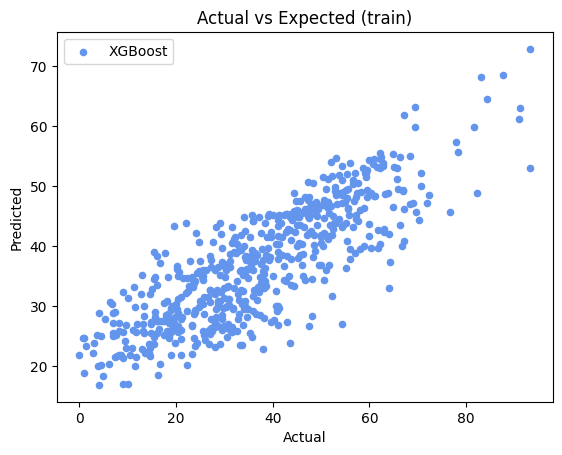

MAE - Test: 12.938835959404514
MAPE - Test: 914692012850723.1
RMSE - Test: 16.202173502731466
R2 - Test: 0.2214253282466987


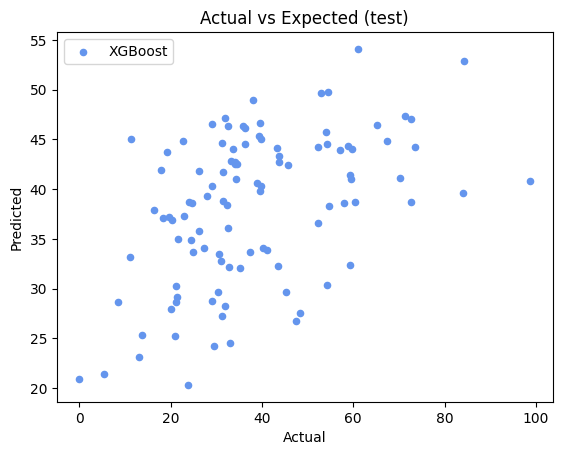

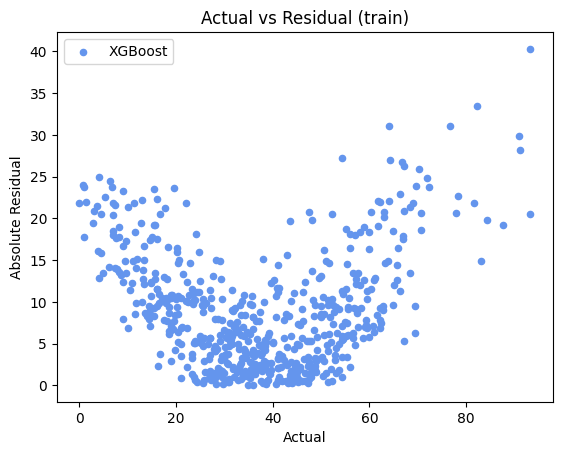

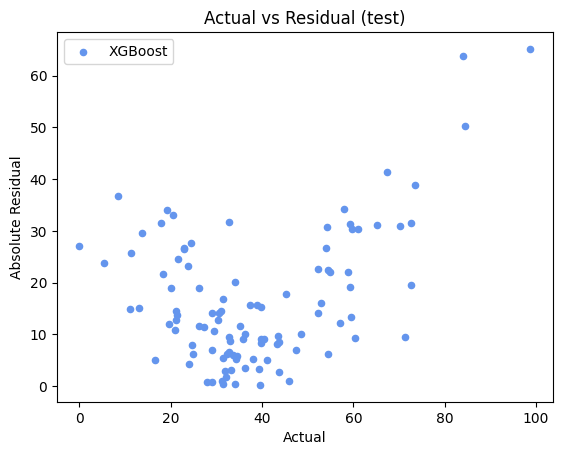

In [64]:
# 5. Model Performance

# 5a. Train Performance Metrics
 
mae_train = mean_absolute_error(y_true = Y_train, y_pred = Y_pred_train)
mape_train = mean_absolute_percentage_error(y_true = Y_train, y_pred = Y_pred_train) 
rmse_train = root_mean_squared_error(y_true = Y_train, y_pred = Y_pred_train) 
r2_train = r2_score(y_true = Y_train, y_pred = Y_pred_train)

print("MAE - Train:", mae_train) 
print("MAPE - Train:", mape_train) 
print("RMSE - Train:", rmse_train)
print("R2 - Train:", r2_train)

  # Actual vs Expected Plots

plt.figure()
plt.scatter(Y_train, Y_pred_train, s = 20, color="cornflowerblue", label=Model_Type)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Expected (train)")
# plt.plot([0, 0], [250, 250], 'k-')
plt.legend()
plt.show()

# 5b. Test Performance Metrics

mae_test = mean_absolute_error(y_true = Y_test, y_pred = Y_pred_test) 
mape_test = mean_absolute_percentage_error(y_true = Y_test, y_pred = Y_pred_test) 
rmse_test = root_mean_squared_error(y_true = Y_test, y_pred = Y_pred_test) 
r2_test = r2_score(y_true = Y_test, y_pred = Y_pred_test)

print("MAE - Test:", mae_test)
print("MAPE - Test:", mape_test)
print("RMSE - Test:", rmse_test)
print("R2 - Test:", r2_test)

  # Actual vs Expected Plots

plt.figure()
plt.scatter(Y_test, Y_pred_test, s = 20, color="cornflowerblue", label= Model_Type)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Expected (test)")
plt.legend()
plt.show()

# 5c. Residual Analysis
  # Train Residuals
Y_train_res = pd.DataFrame(Y_train).reset_index(drop=True)
Y_train_pred = pd.DataFrame(Y_pred_train).reset_index(drop=True)
Y_train_res['pred'] = Y_train_pred[0]
Y_train_res['res'] = Y_train_res['resp_var'] - Y_train_res['pred']
Y_train_res['abs_res'] = abs(Y_train_res['res'])
train_res = pd.concat([Y_train_res, X_train.reset_index(drop=True)], axis=1)

  # Test Residuals
Y_test_res = pd.DataFrame(Y_test).reset_index(drop=True)
Y_test_pred = pd.DataFrame(Y_pred_test).reset_index(drop=True)
Y_test_res['pred'] = Y_test_pred[0]
Y_test_res['res'] = Y_test_res['resp_var'] - Y_train_res['pred']
Y_test_res['abs_res'] = abs(Y_test_res['res'])
test_res = pd.concat([Y_test_res, X_test.reset_index(drop=True)], axis=1)

  # Plots
plt.figure()
plt.scatter(train_res['resp_var'], train_res['abs_res'], s = 20, color="cornflowerblue", label= Model_Type)
plt.xlabel("Actual")
plt.ylabel("Absolute Residual")
plt.title("Actual vs Residual (train)")
plt.legend()
plt.show()


plt.figure()
plt.scatter(test_res['resp_var'], test_res['abs_res'], s = 20, color="cornflowerblue", label= Model_Type)
plt.xlabel("Actual")
plt.ylabel("Absolute Residual")
plt.title("Actual vs Residual (test)")
plt.legend()
plt.show()

# Save Model Object

In [65]:
# Save model object
if save_mdl:
    joblib.dump(model_obj, f'{py_model_directory}{model_name}')
    print(f'Saved {Model_Type} model object as {model_name}')

Saved XGBoost model object as ps_all_mdl_pg5_3
